<br>

<img src="logo_UNSAM.jpg" align="right" width="180" /> 

<br><br><br>

<h3 align="center">Análisis y Procesamiento de Señales</h3>

<h1 align="center"><b>TS0: Primeros pasos en la simulación</b></h1>
<h3 align="center">Paloma Ribnikar Diaz</h3>


## Objetivos
El objetivo del trabajo es diseñar un generador de señales senoidales que permita parametrizar:
   * Amplitud máxima de la senoidal *[Volts]*.
   * Valor medio *[Volts]*.
   * Frecuencia *[Hz]*.
   * Fase *[Rads]*.
   * Cantidad de muestras digitalizada por el ADC *[# muestras]*.
   * Frecuencia de muestreo del ADC *[Hz]*.

## Código en Python

<h3><font color='#9ECE6A'>Librerías y Definiciones</font></h3>

In [17]:
# -*- coding: utf-8 -*-
"""
Created on Mon Aug 17 17:14:25 2026

@author: Paloma Ribnikar Diaz
"""
#%% LIBRERIAS

import numpy as np
import matplotlib.pyplot as plt

#%% DEFINICIONES --> Para simular el ambiente digital

# Parametros fijos del ejercicio
# Del ADC (inherentes a la discretizacion digital)
fs = 1000  # Frecuencia de muestreo (Hz) --> FNyquist = fs/2 = 500Hz
N = 1000  # Cantidad de muestras

# De la funcion senoidal
vmax = 1  # Amplitud pico (volts)
dc = 0  # Valor medio / offset (volts)
ph = 0  # Fase inicial (rad)


<h3><font color='#9ECE6A'>Funciones</font></h3>

In [18]:
#%% FUNCIONES

"""
Funcion señal senoidal
    xx = Vmax * sen (2pi*f*t + ph) + DC 
    --> Conversor ADC, el tiempo no es continuo, entonces: t = n.Ts = n/fs
        tt = n * Ts
        xx = Vmax * sen (2pi*(ff*tt) + ph) + DC 
"""

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    
    # Rango de 0 a N-1 --> tiempo discretoo
    tt =  (np.arange (nn) / fs) #np.arange para generar un vector de N nros
    
    # Señal Senoidal
    xx = vmax * np.sin (2 * np.pi * (ff * tt) + ph) + dc
    
    return tt, xx


<h4><font color='orchid'><b>Análisis previo:</b></font></h4>

$\quad$ La ecuación de señal senoidal corresponde a: $x(t) = V_{\max} \cdot \sin(2\pi \cdot f \cdot t + \phi) + DC$. Esta función es continua en el tiempo, por lo que buscamos discretizarla para poder emular el comportamiento de un ADC. Para ello empleamos el comando "np.arange" en Python, generando una secuencia de $N$ números enteros y construyendo así el vector de tiempo discreto $t = n \cdot T_s = \frac{n}{f_s}$.

$\quad$ La frecuencia de muestreo ${f_s}$ determina el espaciamiento de las réplicas (sus centros) en el dominio frecuencial. La ***Frecuencia de Nyquist*** se define como $f_{\text{Nyquist}} = \frac{f_s}{2}$. Para poder reconstruir la señal original a partir de sus muestras sin perder información ni sufrir solapamiento/distorsión espectral (***Aliasing***), debe cumplirse el ***Teorema de Nyquist-Shannon***, el cual establece que la máxima frecuencia de una señal limitada en banda debe ser estrictamente menor que la Frecuencia de Nyquist ($f < f_{\text{Nyquist}}$):
$$f_{\text{Nyquist}} = \frac{f_s}{2}$$
$$f_{\text{Nyquist}} = 500 \text{ Hz} \quad \text{(en este caso)}$$


<h3><font color='#9ECE6A'>Script</font></h3>

In [19]:
# Llamada de la funcion:
    # tt, xx = mi_funcion_sen(vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)

<h4><font color='#666B88'>Caso base: Frecuencia $f = 1 Hz$</font></h4>

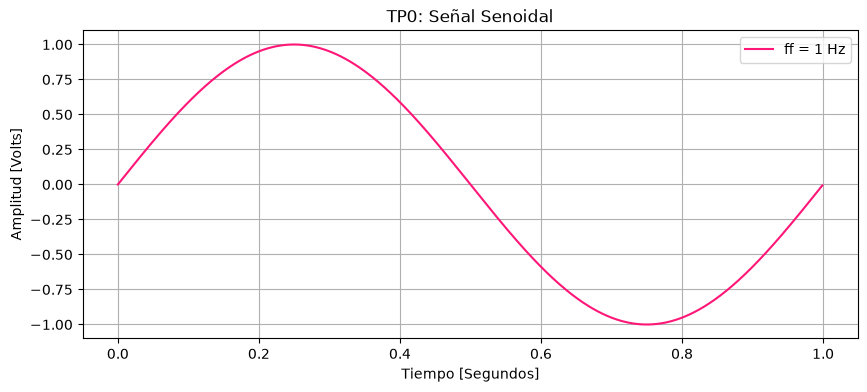

In [20]:
#%% CASO: Frecuencia ff = 1 Hz
tt, xx = mi_funcion_sen(vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)    

# Grafico --> empleo código de intro_a_python 
plt.figure(figsize=(10, 4))
plt.plot(tt, xx, label='ff = 1 Hz', color='#FF1778')
plt.title('TP0: Señal Senoidal')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>

Se observa un ciclo completo en su período $T = 1\text{ s}$ de la función senoidal definida sin distorsión espectral (puesto que $f = 1\text{ Hz} << f_{\text{Nyquist}}$).

<h3><font color='#69ADFF'>BONUS: ALIASING</font></h3>

<h4><font color='#666B88'>Frecuencia $f = 500 Hz$</font></h4>

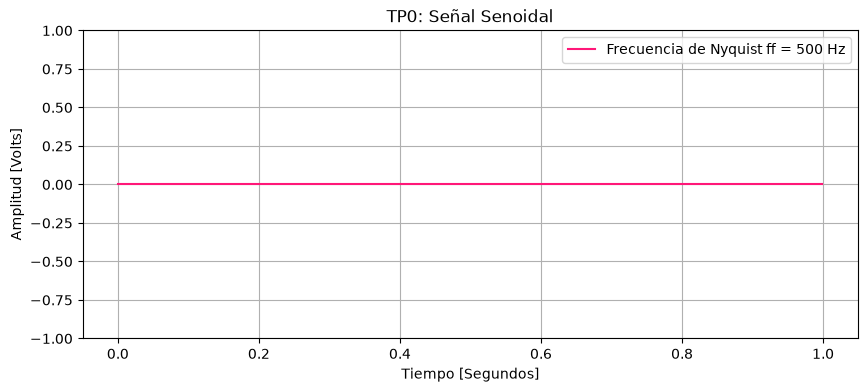

In [21]:
#%%CASO: Frecuencia ff = 500 Hz --> FRECUENCIA DE NYQUIST    
tt, xx = mi_funcion_sen(vmax = 1, dc = 0, ff = 500, ph=0, nn = N, fs = fs)    

# Grafico --> empleo código de intro_a_python 
plt.figure(figsize=(10, 4))
plt.plot(tt, xx, label='Frecuencia de Nyquist ff = 500 Hz', color='#FF1778')
plt.title('TP0: Señal Senoidal')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.legend(loc='upper right')
plt.grid(True)
# picos visibles del orden de 1e-13 V son --> ruido numérico de coma flotante
# entonces, fijo el eje y
plt.ylim(-1, 1)
plt.show()   

<h4><font color='orchid'><b>Análisis:</b></font></h4>

En este caso, $f = 500\text{ Hz} = f_{\text{Nyquist}}$, es decir, nos encontramos en el límite: las réplicas espectrales son tangenciales (no se solapan ni hay espacio entre ellas). En el dominio temporal, teniendo en cuenta que el desfasaje es nulo, las muestras coinciden con los cruces por 0 de la onda ($sin(n\pi) = 0 ∀ n$), resultando en la señal nula visible en el gráfico anterior.

<h4><font color='#666B88'>Frecuencia $f = 999 Hz$</font></h4>

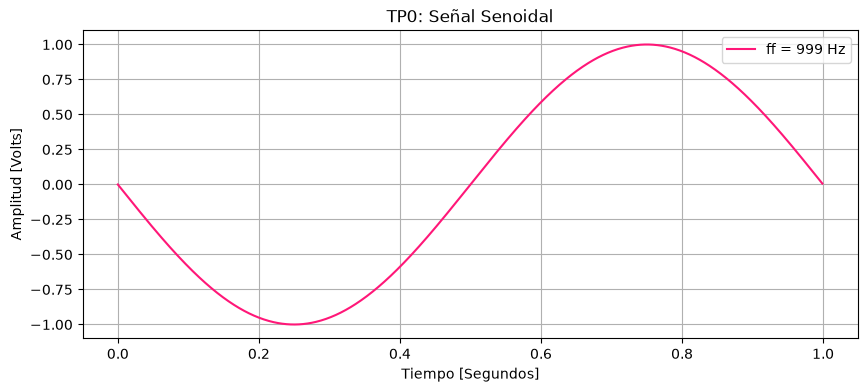

In [22]:
#%%CASO: Frecuencia ff = 999 Hz    
tt, xx = mi_funcion_sen(vmax = 1, dc = 0, ff = 999, ph=0, nn = N, fs = fs)    

# Grafico --> empleo código de intro_a_python 
plt.figure(figsize=(10, 4))
plt.plot(tt, xx, label='ff = 999 Hz', color='#FF1778')
plt.title('TP0: Señal Senoidal')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()   

<h4><font color='orchid'><b>Análisis:</b></font></h4>

La frecuencia de la señal $f = 999\text{ Hz}$ supera la Frecuencia de Nyquist ($f_{\text{Nyquist}} = 500\text{ Hz}$), produciendo solapamiento espectral (*aliasing*). Al encontrarse $1\text{ Hz}$ por debajo de la frecuencia de muestreo ($f_s = 1000\text{ Hz}$), se "convierte" en una senoidal aparente de $1\text{ Hz}$ pero con fase invertida (desfasada $180^\circ$) --> la réplica espectral proyecta su componente de frecuencia en 1Hz con su rama negativa, interpretándose como una frecuencia de tono puro y coincidiendo por ende con la inversa del caso base.

<h4><font color='#666B88'>Frecuencia $f = 1001 Hz$</font></h4>

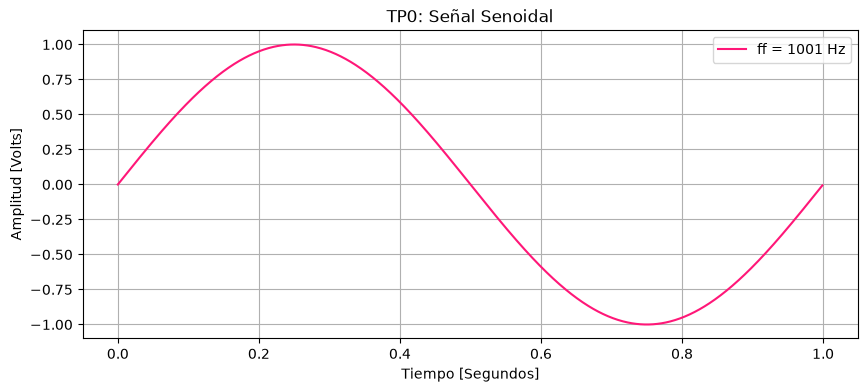

In [23]:
#%%CASO: Frecuencia ff = 1001 Hz       
tt, xx = mi_funcion_sen(vmax = 1, dc = 0, ff = 1001, ph=0, nn = N, fs = fs)    

# Grafico --> empleo código de intro_a_python 
plt.figure(figsize=(10, 4))
plt.plot(tt, xx, label='ff = 1001 Hz', color='#FF1778')
plt.title('TP0: Señal Senoidal')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>

Análogo al caso anterior: La frecuencia de la señal $f = 1001\text{ Hz}$ supera la Frecuencia de Nyquist ($f_{\text{Nyquist}} = 500\text{ Hz}$), generando *aliasing*. Al encontrarse $1\text{ Hz}$ por encima de la frecuencia de muestreo ($f_s = 1000\text{ Hz}$), la señal se representa exactamente como la misma senoidal aparente de $1\text{ Hz}$ de fase directa, siendo indistinguible de la señal base de $1\text{ Hz}$ --> la réplica espectral proyecta su componente de frecuencia en -1Hz con su rama negativa, interpretándose como una frecuencia de tono puro y coincidiendo por ende con el caso base.

<h4><font color='#666B88'>Frecuencia $f = 2001 Hz$</font></h4>

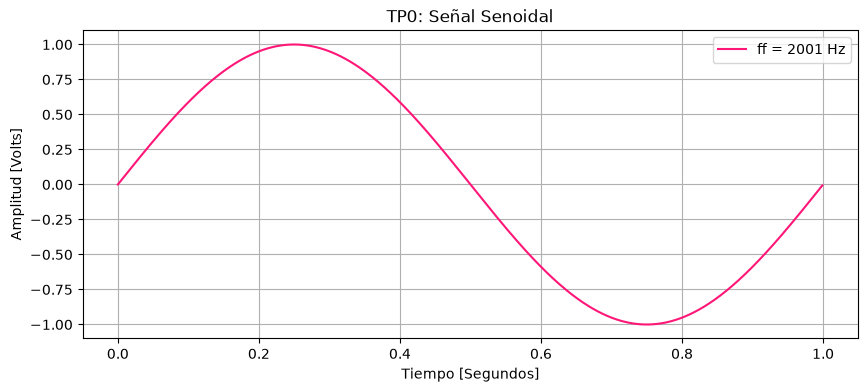

In [24]:
#%%CASO: Frecuencia ff = 2001 Hz   
tt, xx = mi_funcion_sen(vmax = 1, dc = 0, ff = 2001, ph=0, nn = N, fs = fs)    

# Grafico --> empleo código de intro_a_python 
plt.figure(figsize=(10, 4))
plt.plot(tt, xx, label='ff = 2001 Hz', color='#FF1778')
plt.title('TP0: Señal Senoidal')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


<h4><font color='orchid'><b>Análisis:</b></font></h4>

La frecuencia de la señal $f = 2001\text{ Hz}$ supera la Frecuencia de Nyquist ($f_{\text{Nyquist}} = 500\text{ Hz}$). Como supera por $1\text{ Hz}$ el doble de la frecuencia de muestreo ($2 \cdot 1000\text{ Hz}$), se produce *aliasing* y se termina representando en el gráfico la misma onda aparente de $1\text{ Hz}$.

## Conclusión



$\quad$ Con este trabajo semanal se pudo profundizar y aplicar los tópicos teóricos abordados en la materia, específicamente: la frecuencia de Nyquist, el Fenómeno de Aliasing, la discretización del dominio temporal y la implicancia y efecto que tiene variar la frecuencia de la señal senoidal; además de aprender a utilizar y familiarizarnos con el editor de texto Jupyter Notebook y el entorno de desarrollo integrado (IDE), Spyder.
